In [0]:
%matplotlib inline

import pandas
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import time

In [2]:
import os
from google.colab import drive
drive.mount('/content/gdrive', force_remount=False)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Read and Explore Dataset

In [0]:
column_names = ["ReviewerID", "ProductID", "Rating", "Timestamp"]

In [0]:
#df = pd.read_csv("ratings_Electronics.csv",names=column_names)
path = "/content/gdrive/My Drive/AIML/Recommendation Systems/ratings_Electronics.csv"
df = pd.read_csv(path,names=column_names)

In [5]:
df.shape

(7824482, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
ReviewerID    object
ProductID     object
Rating        float64
Timestamp     int64
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


In [7]:
df.describe()

,Rating,Timestamp
count,7.824482e+06,7.824482e+06
mean,4.012337e+00,1.338178e+09
std,1.380910e+00,6.900426e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.315354e+09
50%,5.000000e+00,1.361059e+09
75%,5.000000e+00,1.386115e+09
max,5.000000e+00,1.406074e+09


In [10]:
df.head()

,ReviewerID,ProductID,Rating,Timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [0]:
# The Timestamp here indicates Unix time stamp (i.e., total seconds since January 1st 1970 till the particular time of review).
# Let us add a column Date that converts timestamp into readable format.

In [12]:
df['date'] = pd.to_datetime(df['Timestamp'],unit='s')
df.head()

,ReviewerID,ProductID,Rating,Timestamp,date
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200,2013-04-13
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800,2012-07-01
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600,2013-04-29
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200,2013-07-22
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200,2012-04-18


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f81598c52e8>,
      dtype=object)

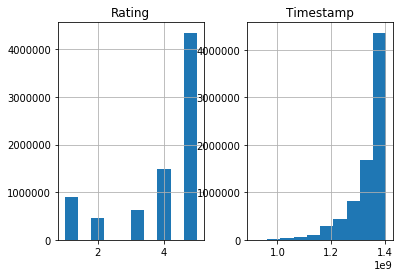

In [13]:
df.hist()

In [35]:
df_sort = df.sort_values('Timestamp',ascending = False)
print("Top 5 recent entries in dataset")
print(df_sort.head())
print()
print("Bottom 5 recent entries in dataset")
print(df_sort.tail())

Top 5 recent entries in dataset
             ReviewerID   ProductID  Rating   Timestamp       date
7516086  A1NXNMRAVPGTO3  B00E98O7GC     5.0  1406073600 2014-07-23
7807561  A1TC07CJU8ROQ2  B00J5OTUOY     5.0  1406073600 2014-07-23
6242775  A2A50YBMOFB4S6  B008HZ595G     5.0  1406073600 2014-07-23
7818529  A30T7JS6OLIYXW  B00K36GUQO     5.0  1406073600 2014-07-23
7823041   ATINSLZVUUGME  B00KMRGF28     5.0  1406073600 2014-07-23

Bottom 5 recent entries in dataset
          ReviewerID   ProductID  Rating  Timestamp       date
8087  A2LG0LV5RI86F0  B00000DM93     5.0  925603200 1999-05-02
8098   AY2NE9ZEZ5LCE  B00000DM9D     5.0  914630400 1998-12-26
8091   AFHLJPG5ZIMNO  B00000DM96     5.0  913939200 1998-12-18
8099  A28AXJL31RXUON  B00000DM9M     4.0  912988800 1998-12-07
8093  A2ZUNCI13N2OUL  B00000DM9D     4.0  912729600 1998-12-04


In [0]:
# Majority of the reviewers have rated as 5 for various Products.
# Reviews span from year 1998 to 2014 and as observed in Histogram, Majority of the Amazon reviews are in year 2014.

### Let us keep the users who have given 50 or more ratings 

In [16]:
df_sub = df[df.groupby('ReviewerID')['ReviewerID'].transform('size') > 49]
df_sub.ReviewerID.value_counts()

A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
ARBKYIVNYWK3C     296
A22CW0ZHY3NJH8    292
A38RMU1Y5TDP9     282
A3EXWV8FNSSFL6    282
A3LGT6UZL99IW1    279
A2NOW4U7W3F7RI    277
A23GFTVIETX7DS    270
A3PD8JD9L4WEII    266
A17BUUBOU0598B    261
A3AYSYSLHU26U9    257
A2XRMQA6PJ5ZJ8    253
A231WM2Z2JL0U3    252
A12DQZKRKTNF5E    252
A1UQBFCERIP7VJ    247
AGVWTYW0ULXHT     244
A203OCQQ12MAVT    240
AEJAGHLC675A7     239
A2NYK9KWFMJV4Y    238
A3A4ZAIBQWKOZS    236
A3CW0ZLUO5X2B1    227
                 ... 
A20ZM879PCQQEZ     50
A1R3GN9MEJFXM3     50
A1QLQCJVGCQPP0     50
A3EP26M3QHINXT     50
A2RS66Y79Q8X0W     50
ANEDXRFDZDL18      50
A3HC7NWLKCPX4X     50
A1LA4K5JF78BER     50
A3BY5KCNQZXV5U     50
A1UNJ46NSB352E     50
A2TVJ0YDW3QO63     50
A2F4HP0J5VNOYR     50
A7Z2J9V37ABCO      50
A11KQADBYE0UZL     50
AOQLV2LSI9

In [19]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 125871 entries, 94 to 7824444
Data columns (total 5 columns):
ReviewerID    125871 non-null object
ProductID     125871 non-null object
Rating        125871 non-null float64
Timestamp     125871 non-null int64
date          125871 non-null datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 5.8+ MB


### Train Test Split

In [0]:
train_data, test_data = train_test_split(df_sub, test_size = 0.30, random_state=7)

In [21]:
pip install scikit-surprise

     |████████████████████████████████| 3.3MB 9.4MB/s 
  Created wheel for scikit-surprise: filename=scikit_surprise-1.0.6-cp36-cp36m-linux_x86_64.whl size=1683493 sha256=9870a93475df399d9f491f602c7a9b99c4822d62043b797497ebd0dd6d9d0406
  Stored in directory: /root/.cache/pip/wheels/ec/c0/55/3a28eab06b53c220015063ebbdb81213cd3dcbb72c088251ec
Successfully built scikit-surprise


### Popularity Model

In [0]:
import sys
sys.path.append('/content/gdrive/My Drive/AIML/Recommendation Systems')

In [0]:
import Recommender_Ratings as rm
pm = rm.popularity_recommender_rating()

In [24]:
# Recommend top K Products for any particular reviewer 
K = 5
pm.create(train_data, 'ReviewerID', 'ProductID', K)
reviewer_id = df_sub['ReviewerID'].values[0]
pm.recommend(reviewer_id)

,ReviewerID,ProductID,score,Rank
30877,A3BY5KCNQZXV5U,B0088CJT4U,146,1.0
19628,A3BY5KCNQZXV5U,B003ES5ZUU,128,2.0
30281,A3BY5KCNQZXV5U,B007WTAJTO,114,3.0
8677,A3BY5KCNQZXV5U,B000N99BBC,107,4.0
31132,A3BY5KCNQZXV5U,B008DWCRQW,105,5.0


### Collaborative Filtering model

In [0]:
from surprise import Reader, Dataset
from surprise import SVD, evaluate
from surprise import accuracy
#from surprise import GridSearch
from surprise.model_selection import KFold, GridSearchCV

In [0]:
ratings_dict = {'itemID': list(df_sub.ProductID),
                'userID': list(df_sub.ReviewerID),
                'rating': list(df_sub.Rating)}
df_dict = pd.DataFrame(ratings_dict)

In [27]:
df_dict.head()

,itemID,userID,rating
0,0594451647,A3BY5KCNQZXV5U,5.0
1,0594481813,AT09WGFUM934H,3.0
2,0970407998,A32HSNCNPRUMTR,1.0
3,0970407998,A17HMM1M7T9PJ1,4.0
4,0972683275,A3CLWR1UUZT6TG,5.0


In [0]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_dict[['userID', 'itemID', 'rating']], reader)

In [0]:
# Split data into 5 folds
data.split(n_folds=5)

In [30]:
algo = SVD()
evaluate(algo, data, measures=['RMSE'])

/usr/local/lib/python3.6/dist-packages/surprise/evaluate.py:66: UserWarning: The evaluate() method is deprecated. Please use model_selection.cross_validate() instead.
  'model_selection.cross_validate() instead.', UserWarning)
/usr/local/lib/python3.6/dist-packages/surprise/dataset.py:193: UserWarning: Using data.split() or using load_from_folds() without using a CV iterator is now deprecated. 
  UserWarning)


Evaluating RMSE of algorithm SVD.

------------
Fold 1
RMSE: 0.9800
------------
Fold 2
RMSE: 0.9862
------------
Fold 3
RMSE: 0.9864
------------
Fold 4
RMSE: 0.9880
------------
Fold 5
RMSE: 0.9754
------------
------------
Mean RMSE: 0.9832
------------
------------


CaseInsensitiveDefaultDict(list,
                           {'rmse': [0.9800201342679371,
                             0.9862199677765844,
                             0.9863561325371999,
                             0.9880459699652809,
                             0.975354461377966]})

In [31]:
param_grid = {
    "n_epochs": [5, 10],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.4, 0.6]
}
gs = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3)

gs.fit(data)

print(gs.best_score["rmse"])
print(gs.best_params["rmse"])

0.9888781321488015
{'n_epochs': 10, 'lr_all': 0.005, 'reg_all': 0.4}


### Non-negative matrix factorization (NMF) 

In [32]:
from surprise import NMF
algo = NMF()
evaluate(algo, data, measures=['RMSE'])

/usr/local/lib/python3.6/dist-packages/surprise/evaluate.py:66: UserWarning: The evaluate() method is deprecated. Please use model_selection.cross_validate() instead.
  'model_selection.cross_validate() instead.', UserWarning)
/usr/local/lib/python3.6/dist-packages/surprise/dataset.py:193: UserWarning: Using data.split() or using load_from_folds() without using a CV iterator is now deprecated. 
  UserWarning)


Evaluating RMSE of algorithm NMF.

------------
Fold 1
RMSE: 1.1430
------------
Fold 2
RMSE: 1.1500
------------
Fold 3
RMSE: 1.1503
------------
Fold 4
RMSE: 1.1499
------------
Fold 5
RMSE: 1.1280
------------
------------
Mean RMSE: 1.1442
------------
------------


CaseInsensitiveDefaultDict(list,
                           {'rmse': [1.1429994213200232,
                             1.1499820802153389,
                             1.150321132038823,
                             1.1498694541821843,
                             1.1280474759514014]})

### Let us also try with turicreate package that provides a unified interface for Recommender models.

In [0]:
import turicreate as tc
sf = tc.SFrame(data=df)

In [0]:
sf.show

<bound method SFrame.show of Columns:
	ReviewerID	str
	ProductID	str
	Rating	float
	Timestamp	int

Rows: 7824482

Data:
+----------------+------------+--------+------------+
|   ReviewerID   | ProductID  | Rating | Timestamp  |
+----------------+------------+--------+------------+
| AKM1MP6P0OYPR  | 0132793040 |  5.0   | 1365811200 |
| A2CX7LUOHB2NDG | 0321732944 |  5.0   | 1341100800 |
| A2NWSAGRHCP8N5 | 0439886341 |  1.0   | 1367193600 |
| A2WNBOD3WNDNKT | 0439886341 |  3.0   | 1374451200 |
| A1GI0U4ZRJA8WN | 0439886341 |  1.0   | 1334707200 |
| A1QGNMC6O1VW39 | 0511189877 |  5.0   | 1397433600 |
| A3J3BRHTDRFJ2G | 0511189877 |  2.0   | 1397433600 |
| A2TY0BTJOTENPG | 0511189877 |  5.0   | 1395878400 |
| A34ATBPOK6HCHY | 0511189877 |  5.0   | 1395532800 |
| A89DO69P0XZ27  | 0511189877 |  5.0   | 1395446400 |
+----------------+------------+--------+------------+
[7824482 rows x 4 columns]
Note: Only the head of the SFrame is printed.
You can use print_rows(num_rows=m, num_columns=n) t

In [0]:
# Let us start with Popularity model 
model = tc.recommender.popularity_recommender.create(sf,
                                          user_id='ReviewerID',
                                    item_id='ProductID',
                                    target='Rating')

Warning: Ignoring columns Timestamp;

To use these columns in scoring predictions, use a model that allows the use of additional features.

Preparing data set.

Data has 7824482 observations with 4201696 users and 476002 items.

Data prepared in: 9.0851s

7824482 observations to process; with 476002 unique items.

In [0]:
## Find out recommended Products for Users
most_popular = model.recommend(users=[1,2,3,4,5],k=3)
most_popular = most_popular.join(right=sf,on={'ProductID':'ProductID'},how='inner').sort(['ReviewerID','rank'], ascending=True)
most_popular.print_rows(num_rows=20)

+------------+------------+-------+------+----------------+--------+------------+
| ReviewerID | ProductID  | score | rank |  ReviewerID.1  | Rating | Timestamp  |
+------------+------------+-------+------+----------------+--------+------------+
|     1      | 059400232X |  5.0  |  1   | AZQZ3STMCBG5H  |  5.0   | 1395705600 |
|     1      | 059400232X |  5.0  |  1   | A22FB2WSZSXSHH |  5.0   | 1348790400 |
|     1      | 059400232X |  5.0  |  1   | A2WOJCFAWI8VS8 |  5.0   | 1379376000 |
|     1      | 0321732944 |  5.0  |  2   | A2CX7LUOHB2NDG |  5.0   | 1341100800 |
|     1      | 0132793040 |  5.0  |  3   | AKM1MP6P0OYPR  |  5.0   | 1365811200 |
|     2      | 059400232X |  5.0  |  1   | AZQZ3STMCBG5H  |  5.0   | 1395705600 |
|     2      | 059400232X |  5.0  |  1   | A22FB2WSZSXSHH |  5.0   | 1348790400 |
|     2      | 059400232X |  5.0  |  1   | A2WOJCFAWI8VS8 |  5.0   | 1379376000 |
|     2      | 0321732944 |  5.0  |  2   | A2CX7LUOHB2NDG |  5.0   | 1341100800 |
|     2      | 0

In [0]:
# Let us now try with Collaborative Filtering model
training_data, validation_data = tc.recommender.util.random_split_by_user(sf, 'ReviewerID', 'ProductID',item_test_proportion=0.3)
cfmodel = tc.recommender.item_similarity_recommender.create(training_data,
                                          user_id='ReviewerID',
                                    item_id='ProductID',
                                    target='Rating')
items_similarity = model.get_similar_items()

Warning: Ignoring columns Timestamp;

To use these columns in scoring predictions, use a model that allows the use of additional features.

Preparing data set.

Data has 7823981 observations with 4201500 users and 475988 items.

Data prepared in: 9.01239s

...

| 6.02s                               | 100              | 475988          |

+-------------------------------------+------------------+-----------------+

Finalizing lookup tables.

Generating candidate set for working with new users.

Finished training in 6.50851s

In [0]:
cfmodel.evaluate(validation_data)


Precision and recall summary statistics by cutoff
+--------+----------------------+----------------------+
| cutoff |    mean_precision    |     mean_recall      |
+--------+----------------------+----------------------+
|   1    | 0.01652892561983471  | 0.012855831037649227 |
|   2    | 0.012396694214876021 | 0.019742883379247046 |
|   3    | 0.009182736455463731 | 0.02066115702479341  |
|   4    | 0.008264462809917357 | 0.02617079889807163  |
|   5    | 0.007713498622589538 | 0.031680440771349884 |
|   6    | 0.006427915518824611 | 0.031680440771349884 |
|   7    | 0.005903187721369538 | 0.034435261707988975 |
|   8    | 0.006198347107438016 | 0.04269972451790634  |
|   9    | 0.00581573308846036  | 0.04545454545454546  |
|   10   | 0.005234159779614327 | 0.04545454545454546  |
+--------+----------------------+----------------------+
[10 rows x 3 columns]


Overall RMSE: 4.298281554686311

Per User RMSE (best)
+----------------+-------------------+-------+
|   ReviewerID   |        

{'precision_recall_by_user': Columns:
 	ReviewerID	str
 	cutoff	int
 	precision	float
 	recall	float
 	count	int
 
 Rows: 6534
 
 Data:
 +----------------+--------+-----------+--------+-------+
 |   ReviewerID   | cutoff | precision | recall | count |
 +----------------+--------+-----------+--------+-------+
 | A2J6DH44PTUU1S |   1    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   2    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   3    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   4    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   5    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   6    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   7    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   8    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   9    |    0.0    |  0.0   |   2   |
 | A2J6DH44PTUU1S |   10   |    0.0    |  0.0   |   2   |
 +----------------+--------+-----------+--------+-------+
 [6534 rows x 5 columns]
 Note: Only the head of the

### Insights
Majority of the reviewers have rated as 5 for various Products.
Reviews span from year 1998 to 2014 and majority (more than 50%) are in year 2014.
Among all the models (including Surprise and Turi Create libraries), the Collaborative Filtering Model using Singular Value Decomposition (SVD) has performed better for the given dataset with best RMSE score of 0.989.



